<a href="https://colab.research.google.com/github/esther119/Bayesian-Statistics/blob/main/CS146_Session_24_The_Metropolis_Hastings_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import scipy.stats as sts
import matplotlib.pyplot as plt
import random 

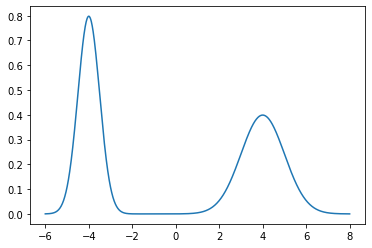

In [2]:
x = np.linspace(-6, 8, 1000)

def p_function(points):
    return sts.norm.pdf(points, loc=-4, scale=0.5) + sts.norm.pdf(points, loc=4, scale=1)

plt.plot(x, p_function(x))

In [21]:
def random_uniform(p): #function to accept or reject the new sample 
    unif = random.uniform(0,1)
    if p >= unif:
        return True
    else:
        return False

In [ ]:
def q_function(data, loc, sigma):
    return sts.norm.pdf(data, loc=loc, scale=sigma)

In [43]:
def mcmc(t,mu,sigma):
    states = [] #store all the samples 
    reject = 0  #numbers of new samples rejected
    current = random.uniform(-5*sigma+mu,5*sigma+mu)
    for _ in range(t):
        states.append(current)
        movement = sts.norm.rvs(loc=current, scale=sigma)
        
        curr_prob = p_function(current)
        move_prob = p_function(movement)
        
        acceptance = min(move_prob/curr_prob,1)
        if random_uniform(acceptance):
            current = movement
        else: 
          reject += 1
    return states, reject

In [54]:
def plot_acf(x): 
    '''
    Plot the autocorrelation function for a series x. This corresponds to the
    acf() function in R. The series x is detrended by subtracting the mean of
    the series before computing the autocorrelation.
    The autocorrelation at lag = 0 is always 1 since the series is perfectly
    correlated with itself. You can ignore this value. The autocorrelation at
    all other values should be as small as possible, since independent samples
    have no correlation.
    '''
    from scipy import signal
    import matplotlib.pyplot as plt 
    plt.acorr(
        x, maxlags=20, detrend=lambda x: signal.detrend(x, type='constant')
    )


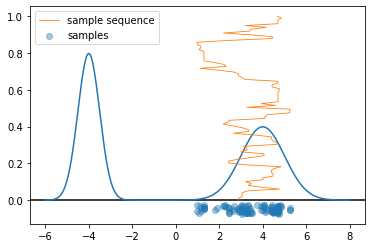

Acceptance rate = 0.6699999999999999


In [50]:
t = 100
samples, reject = mcmc(t,mu=0,sigma=1)
# plt.hist(dist,bins=20) 
plt.axhline(0, c="black")
plt.plot(x, p_function(x))
plt.plot(samples, np.linspace(0, 1, len(samples)), linewidth=0.8, label="sample sequence")
plt.scatter(samples, sts.uniform.rvs(loc=-0.075, scale=0.05, size=len(samples)), alpha=0.4, label="samples")
plt.legend()
plt.show()

print(f'Acceptance rate = {1- reject/ t}')

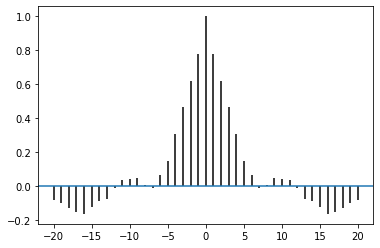

In [55]:
plot_acf(samples)

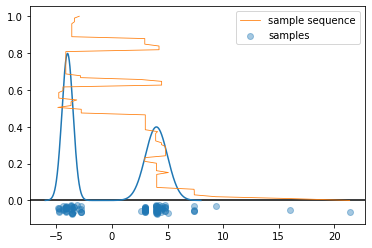

Acceptance rate = 0.28


In [56]:
t = 100
samples, reject = mcmc(t,mu=0,sigma=5) #change to different sigma
# plt.hist(dist,bins=20) 
plt.axhline(0, c="black")
plt.plot(x, p_function(x))
plt.plot(samples, np.linspace(0, 1, len(samples)), linewidth=0.8, label="sample sequence")
plt.scatter(samples, sts.uniform.rvs(loc=-0.075, scale=0.05, size=len(samples)), alpha=0.4, label="samples")
plt.legend()
plt.show()

print(f'Acceptance rate = {1- reject/ t}')

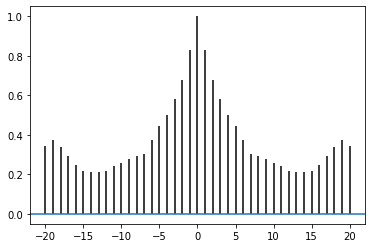

In [57]:
plot_acf(samples)

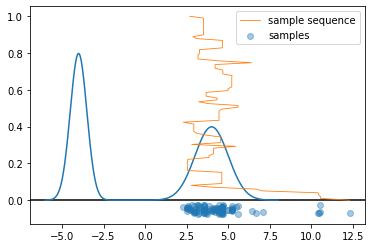

Acceptance rate = 0.42000000000000004


In [52]:
t = 100
samples, reject = mcmc(t,mu=0,sigma=3) #change to different sigma
# plt.hist(dist,bins=20) 
plt.axhline(0, c="black")
plt.plot(x, p_function(x))
plt.plot(samples, np.linspace(0, 1, len(samples)), linewidth=0.8, label="sample sequence")
plt.scatter(samples, sts.uniform.rvs(loc=-0.075, scale=0.05, size=len(samples)), alpha=0.4, label="samples")
plt.legend()
plt.show()

print(f'Acceptance rate = {1- reject/ t}')

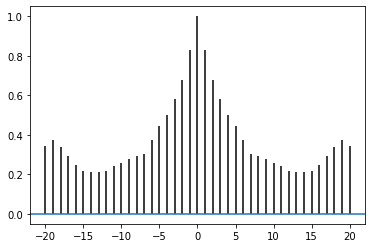

In [58]:
plot_acf(samples)